# MAgent2 PyTorch MFRL Baselines

Train reference-style PyTorch MFRL baselines on MAgent2 `battle_v4`: Individual Q-Learning (`iql`), Individual Actor-Critic (`ac`), and Mean Field Q-Learning (`mfq`). The algorithm/network code follows `mfrl_pytorch-master`; this notebook uses the project helper for synchronous vectorized rollout collection.

In [1]:
from pathlib import Path
import sys
import torch
import pandas as pd


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.mfrl_baselines import (
    DEFAULT_MFRL_TASK_CONFIG,
    train_mfrl_baseline,
)
from discrete_action_space.mean_field_dsrq.notebook_utils import (
    baseline_rollout_video_from_notebook,
    find_latest_mfrl_run,
    plot_mfrl_baseline_training_curves,
)

TASK_CONFIG = {
    **DEFAULT_MFRL_TASK_CONFIG,
    "env_name": "battle_v4",
    "map_size": 40,
    "max_cycles": 400,
}
TARGET_EPISODES = 2000
NUM_ENVS = 8
MAX_STEPS = 50
REWARD_LOG_INTERVAL = 100
MAX_TRAIN_BATCHES_PER_UPDATE = None
MAX_POLICY_SAMPLES_PER_UPDATE = None
SMOOTHING_WINDOW = 20
SEED = 42
SAVE_FOLDER = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs" / "mfrl_baselines"
SAVE_FOLDER.mkdir(parents=True, exist_ok=True)
BASELINE_RUN_DIRS = {}
for algorithm in ("iql", "ac", "mfq"):
    try:
        BASELINE_RUN_DIRS[algorithm] = find_latest_mfrl_run(algorithm, SAVE_FOLDER)
    except FileNotFoundError:
        pass
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

common_kwargs = dict(
    task_config=TASK_CONFIG,
    target_episodes=TARGET_EPISODES,
    num_envs=NUM_ENVS,
    seed=SEED,
    save_folder=SAVE_FOLDER,
    device=DEVICE,
    reward_log_interval=REWARD_LOG_INTERVAL,
    max_train_batches_per_update=MAX_TRAIN_BATCHES_PER_UPDATE,
    max_policy_samples_per_update=MAX_POLICY_SAMPLES_PER_UPDATE,
)
BASELINE_RUN_DIRS
print(DEVICE)


cuda


## IQL

In [2]:
iql_result = train_mfrl_baseline("iql", **common_kwargs)


IQL episodes:   0%|          | 0/2000 [00:00<?, ?ep/s]

[iql] episodes=100/2000 mean_main_reward=-1000.489 mean_opponent_reward=-1005.927
[iql] episodes=200/2000 mean_main_reward=-972.833 mean_opponent_reward=-968.482
[iql] episodes=300/2000 mean_main_reward=-960.356 mean_opponent_reward=-945.548
[iql] episodes=400/2000 mean_main_reward=-951.170 mean_opponent_reward=-936.472
[iql] episodes=500/2000 mean_main_reward=-946.331 mean_opponent_reward=-928.110
[iql] episodes=600/2000 mean_main_reward=-937.232 mean_opponent_reward=-917.188
[iql] episodes=700/2000 mean_main_reward=-923.014 mean_opponent_reward=-906.244
[iql] episodes=800/2000 mean_main_reward=-908.006 mean_opponent_reward=-883.413
[iql] episodes=900/2000 mean_main_reward=-867.758 mean_opponent_reward=-836.079
[iql] episodes=1000/2000 mean_main_reward=-747.769 mean_opponent_reward=-673.385
[iql] episodes=1100/2000 mean_main_reward=-308.589 mean_opponent_reward=-264.229
[iql] episodes=1200/2000 mean_main_reward=-23.323 mean_opponent_reward=-117.884
[iql] episodes=1300/2000 mean_main_r

Saved training curves to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/iql_battle_v4_seed42_26_06_03-02_14_06/training_reward_wins_and_kills.png


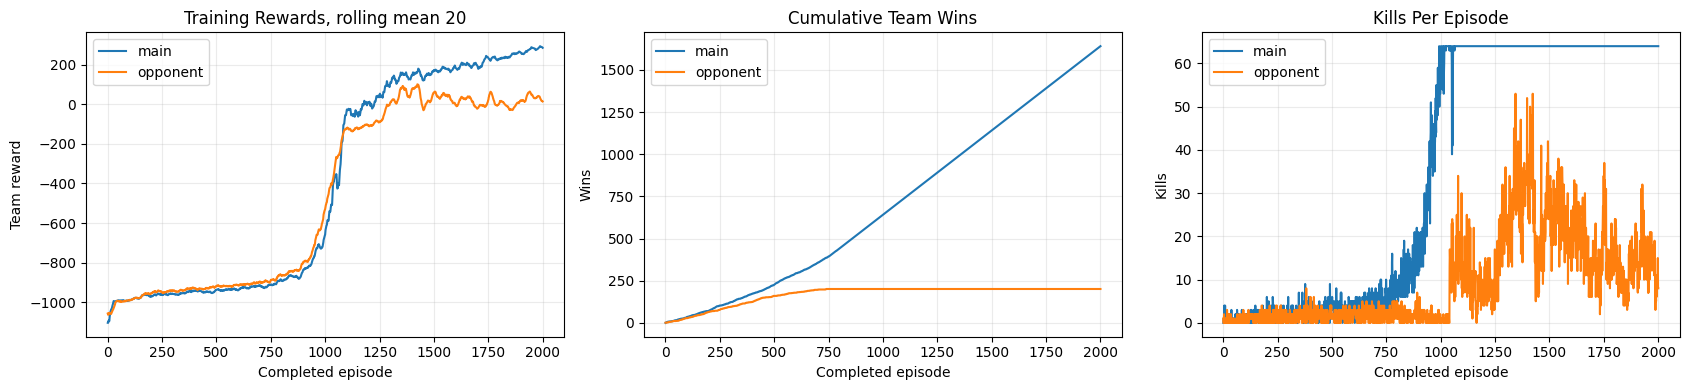

In [14]:
_ = plot_mfrl_baseline_training_curves(iql_result, smoothing_window=SMOOTHING_WINDOW)


## IQL Evaluation Rollout

In [4]:
baseline_rollout_video_from_notebook(
    iql_result,
    max_steps=MAX_STEPS,
    fps=8,
    deterministic=True,
    title="IQL evaluation rollout",
)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## AC

In [5]:
ac_result = train_mfrl_baseline("ac", **common_kwargs)


AC episodes:   0%|          | 0/2000 [00:00<?, ?ep/s]

[ac] episodes=100/2000 mean_main_reward=-879.953 mean_opponent_reward=-857.835
[ac] episodes=200/2000 mean_main_reward=-591.403 mean_opponent_reward=-602.163
[ac] episodes=300/2000 mean_main_reward=-484.884 mean_opponent_reward=-466.888
[ac] episodes=400/2000 mean_main_reward=-492.880 mean_opponent_reward=-451.942
[ac] episodes=500/2000 mean_main_reward=-526.347 mean_opponent_reward=-455.643
[ac] episodes=600/2000 mean_main_reward=-515.844 mean_opponent_reward=-451.389
[ac] episodes=700/2000 mean_main_reward=-510.029 mean_opponent_reward=-454.026
[ac] episodes=800/2000 mean_main_reward=-512.878 mean_opponent_reward=-453.984
[ac] episodes=900/2000 mean_main_reward=-513.158 mean_opponent_reward=-451.231
[ac] episodes=1000/2000 mean_main_reward=-511.271 mean_opponent_reward=-453.789
[ac] episodes=1100/2000 mean_main_reward=-516.100 mean_opponent_reward=-452.790
[ac] episodes=1200/2000 mean_main_reward=-507.802 mean_opponent_reward=-451.975
[ac] episodes=1300/2000 mean_main_reward=-515.654

Saved training curves to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/ac_battle_v4_seed42_26_06_02-19_30_51/training_reward_wins_and_kills.png


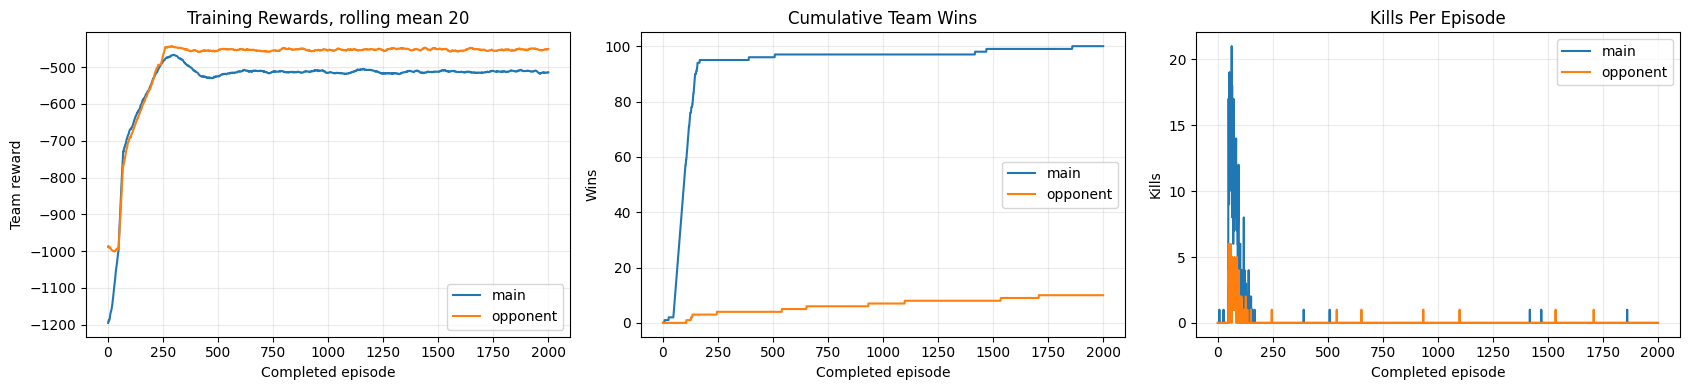

In [6]:
_ = plot_mfrl_baseline_training_curves(BASELINE_RUN_DIRS["ac"], smoothing_window=SMOOTHING_WINDOW)


## AC Evaluation Rollout

In [7]:
baseline_rollout_video_from_notebook(
    ac_result,
    max_steps=MAX_STEPS,
    fps=8,
    deterministic=True,
    title="AC evaluation rollout",
)


## MFQ

In [8]:
mfq_result = train_mfrl_baseline("mfq", **common_kwargs)


MFQ episodes:   0%|          | 0/2000 [00:00<?, ?ep/s]

[mfq] episodes=100/2000 mean_main_reward=-1004.331 mean_opponent_reward=-1001.767
[mfq] episodes=200/2000 mean_main_reward=-976.039 mean_opponent_reward=-977.657
[mfq] episodes=300/2000 mean_main_reward=-963.776 mean_opponent_reward=-966.486
[mfq] episodes=400/2000 mean_main_reward=-959.084 mean_opponent_reward=-960.195
[mfq] episodes=500/2000 mean_main_reward=-948.243 mean_opponent_reward=-951.327
[mfq] episodes=600/2000 mean_main_reward=-939.989 mean_opponent_reward=-941.969
[mfq] episodes=700/2000 mean_main_reward=-928.105 mean_opponent_reward=-932.760
[mfq] episodes=800/2000 mean_main_reward=-917.639 mean_opponent_reward=-921.366
[mfq] episodes=900/2000 mean_main_reward=-868.947 mean_opponent_reward=-872.107
[mfq] episodes=1000/2000 mean_main_reward=-667.075 mean_opponent_reward=-621.199
[mfq] episodes=1100/2000 mean_main_reward=-218.453 mean_opponent_reward=-225.376
[mfq] episodes=1200/2000 mean_main_reward=23.273 mean_opponent_reward=-66.971
[mfq] episodes=1300/2000 mean_main_rew

Saved training curves to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/mfq_battle_v4_seed42_26_06_03-03_00_45/training_reward_wins_and_kills.png


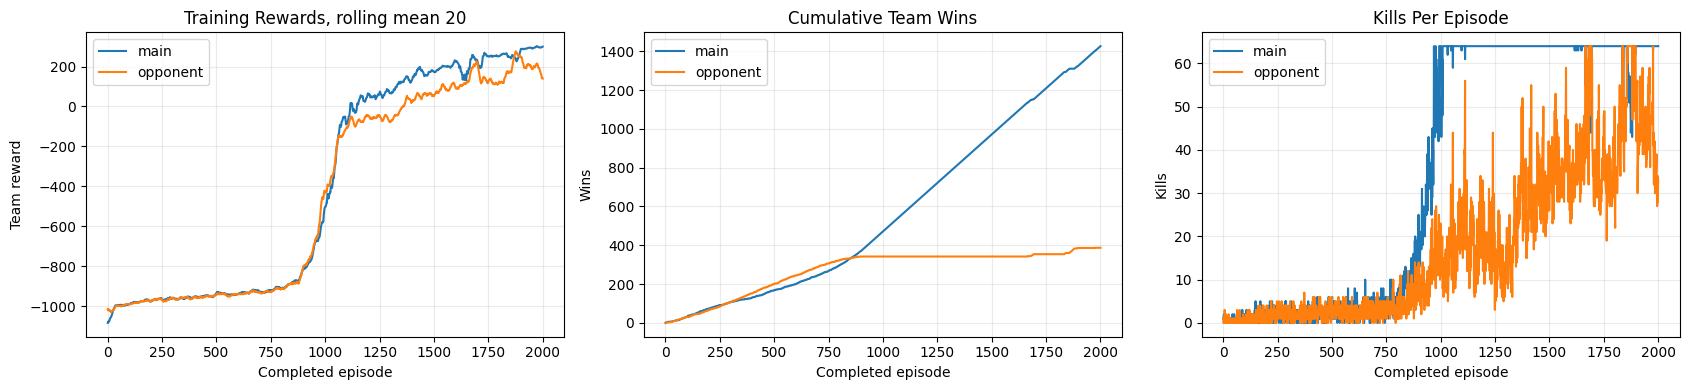

In [12]:
_ = plot_mfrl_baseline_training_curves(mfq_result, smoothing_window=SMOOTHING_WINDOW)


## MFQ Evaluation Rollout

In [10]:
baseline_rollout_video_from_notebook(
    mfq_result,
    max_steps=MAX_STEPS,
    fps=8,
    deterministic=True,
    title="MFQ evaluation rollout",
)


## Comparison

In [11]:
baseline_results = [iql_result, ac_result, mfq_result]
pd.DataFrame([
    {
        "algorithm": result["algorithm"],
        "completed_episodes": result["completed_episodes"],
        "num_envs": result["num_envs"],
        "device": result["device"],
        "main_win_rate": result["summary"].get("main_win_rate"),
        "opponent_win_rate": result["summary"].get("opponent_win_rate"),
        "tie_rate": result["summary"].get("tie_rate"),
        "run_dir": result["run_dir"],
    }
    for result in baseline_results
])


,algorithm,completed_episodes,num_envs,device,main_win_rate,opponent_win_rate,tie_rate,run_dir
0,iql,2000,8,cuda,0.8205,0.1005,0.0790,/home/wowthecoder/SRE-DQN/discrete_action_spac...
1,ac,2000,8,cuda,0.0500,0.0050,0.9450,/home/wowthecoder/SRE-DQN/discrete_action_spac...
2,mfq,2000,8,cuda,0.7130,0.1935,0.0935,/home/wowthecoder/SRE-DQN/discrete_action_spac...
